# Model ladder: portfolio-first day-ahead evidence

**Decision question.** What should the team use for 96-quarter-hour forecasts issued at 00:00 UTC, and what evidence supports the next experiment? All target lags are origin-relative; realized target-day weather is an explicitly labelled oracle and cannot win operational selection.

> This executed evidence build uses all 90 calibration and 275 test origins. To keep the checked-in run reproducible on a laptop, the fitted global models use every seventh training origin and 40 trees. `model_config.json` preserves the production contract (all daily origins, 400 trees). Baselines, evaluation rows, cohort selection, coverage filters, and robustness evaluation are not shortened.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
ART = ROOT / 'artifacts' / 'model_ladder'
config = json.loads((ART / 'model_config.json').read_text())
pred = pd.read_parquet(ART / 'portfolio_predictions.parquet')
overall = pd.read_csv(ART / 'overall_metrics.csv')
sliced = pd.read_csv(ART / 'sliced_metrics.csv')
household = pd.read_parquet(ART / 'household_metrics.parquet')
importance = pd.read_csv(ART / 'feature_importance.csv')
validation = pd.read_csv(ART / 'validation_metrics.csv')
for c in ['origin', 'target_timestamp']: pred[c] = pd.to_datetime(pred[c], utc=True)
winner = config['selected_operational_model']
sns.set_theme(style='whitegrid', context='notebook')
print(f"Loaded {len(pred):,} portfolio predictions; validation-selected winner: {winner}.")
print(f"Primary cohort: {config['primary_cohort']['size']} households; execution mode: {config['execution_mode']}.")

Loaded 202,752 portfolio predictions; validation-selected winner: daily_weekly_ensemble.
Primary cohort: 139 households; execution mode: quick.


## 1. Forecast contract, cohorts, and split timeline

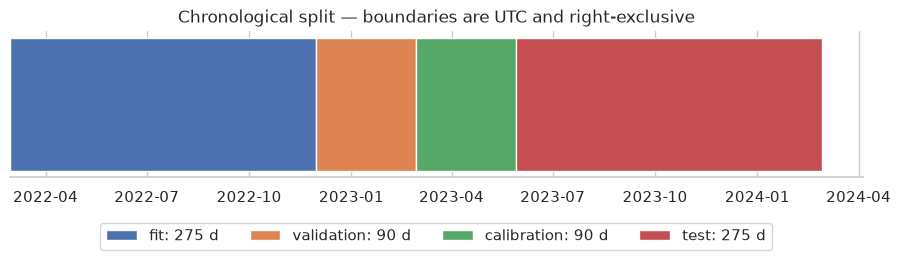

,contract,value
0,origin,00:00 UTC
1,horizon,96 × 15 min
2,lags,"[1, 4, 96, 192, 672]"
3,minimum score coverage,98%
4,primary / robustness cohort,139 / 343 households


In [2]:
split = config['split_spec']
segments = [('fit', split['fit_start'], split['validation_start']), ('validation', split['validation_start'], split['calibration_start']), ('calibration', split['calibration_start'], split['test_start']), ('test', split['test_start'], split['test_end'])]
fig, ax = plt.subplots(figsize=(11, 1.9))
colors = sns.color_palette('deep', 4)
for i, (name, left, right) in enumerate(segments):
    left, right = pd.Timestamp(left), pd.Timestamp(right)
    ax.barh(0, (right-left).days, left=left, height=.5, color=colors[i], label=f'{name}: {(right-left).days} d')
ax.set_yticks([]); ax.set_title('Chronological split — boundaries are UTC and right-exclusive'); ax.legend(ncol=4, loc='lower center', bbox_to_anchor=(.5, -0.55)); sns.despine(left=True)
plt.show()
pd.DataFrame({'contract': ['origin', 'horizon', 'lags', 'minimum score coverage', 'primary / robustness cohort'], 'value': ['00:00 UTC', '96 × 15 min', str(config['forecast_spec']['lags']), '98%', f"139 / {config['robustness']['cohort_size']} households"]})

## 2. Leakage and feature-availability assertions
Targets are never interpolated: series are segmented at gaps. Target and past-covariate timestamps must be strictly before the origin. Calendar is the only operational feature allowed across the forecast horizon; realized weather is isolated in `lightgbm_oracle_bottom_up`.

In [3]:
from utils.modeling import SplitSpec, choose_operational_winner
spec = SplitSpec(**{k: pd.Timestamp(v) for k, v in split.items()})
intervals = list(spec.intervals().values())
assert all(a[1] == b[0] for a, b in zip(intervals, intervals[1:]))
assert config['oracle_eligible_for_selection'] is False
assert choose_operational_winner(validation).model == winner
assert pred.groupby('model').origin.nunique().min() > 250
row_counts = pred.groupby('model').size(); assert row_counts.nunique() == 1
audit = pd.Series({'split_non_overlap': 'PASS', 'origin-relative Darts lags': config['darts_lag_equivalence_test'], 'oracle barred from selection': 'PASS', 'identical test rows': f'PASS ({row_counts.iloc[0]:,} per model)', 'test origins retained': int(pred.groupby('model').origin.nunique().min()), 'training stride': config['training_stride']})
audit.to_frame('result')

,result
split_non_overlap,PASS
origin-relative Darts lags,passed by tests/test_modeling.py
oracle barred from selection,PASS
identical test rows,"PASS (25,344 per model)"
test origins retained,264
training stride,96


## 3–4. Baselines, linear benchmark, and operational LightGBM ladder

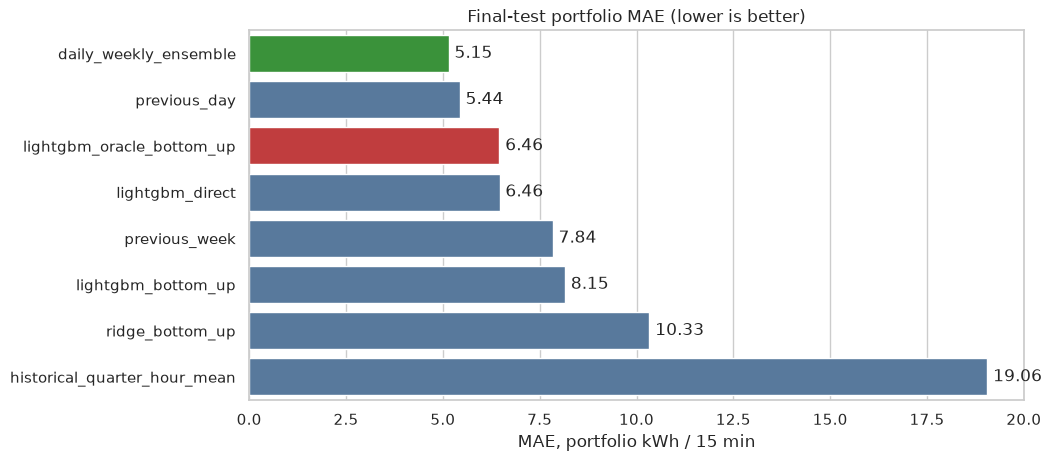

,model,mae,wape,bias,asymmetric_cost_index,training_seconds,prediction_coverage,is_oracle,selected_on_validation
0,daily_weekly_ensemble,5.150,0.134,-0.126,5.175,0.000,0.96,False,True
1,previous_day,5.436,0.141,-0.082,5.453,0.000,0.96,False,False
7,lightgbm_oracle_bottom_up,6.460,0.167,-0.202,6.500,1.144,0.96,True,False
2,lightgbm_direct,6.464,0.168,-1.050,6.673,0.347,0.96,False,False
3,previous_week,7.836,0.203,-0.537,7.944,0.000,0.96,False,False
4,lightgbm_bottom_up,8.154,0.211,0.693,8.015,1.240,0.96,False,False
5,ridge_bottom_up,10.331,0.268,-0.557,10.442,0.073,0.96,False,False
6,historical_quarter_hour_mean,19.056,0.494,0.877,18.880,0.000,0.96,False,False


In [4]:
board = overall.sort_values('mae').copy()
fig, ax = plt.subplots(figsize=(10, 4.8))
palette = ['#d62728' if x else ('#2ca02c' if m == winner else '#4c78a8') for x, m in zip(board.is_oracle, board.model)]
sns.barplot(data=board, y='model', x='mae', palette=palette, hue='model', legend=False, ax=ax)
ax.set(title='Final-test portfolio MAE (lower is better)', xlabel='MAE, portfolio kWh / 15 min', ylabel='')
for p, value in zip(ax.patches, board.mae): ax.text(value+.15, p.get_y()+p.get_height()/2, f'{value:.2f}', va='center')
plt.show()
board[['model','mae','wape','bias','asymmetric_cost_index','training_seconds','prediction_coverage','is_oracle','selected_on_validation']].round(3)

## 5–7. Weather value, direct versus bottom-up, runtime and coverage
Red denotes the unavailable realized-weather oracle. Its gap to the no-weather global model estimates weather information value, not deployable performance.

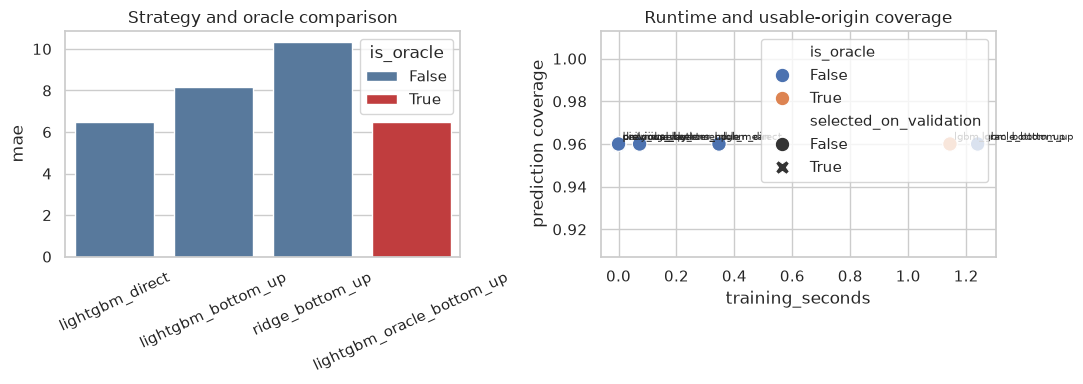

Realized weather oracle improves global LightGBM MAE by 20.8%; archived forecast weather is the next fair test.


In [5]:
focus_names = ['ridge_bottom_up','lightgbm_bottom_up','lightgbm_oracle_bottom_up','lightgbm_direct']
focus = overall[overall.model.isin(focus_names)].copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=focus, x='model', y='mae', hue='is_oracle', palette={False:'#4c78a8', True:'#d62728'}, ax=axes[0])
axes[0].tick_params(axis='x', rotation=25); axes[0].set(xlabel='', title='Strategy and oracle comparison')
sns.scatterplot(data=overall, x='training_seconds', y='prediction_coverage', hue='is_oracle', style='selected_on_validation', s=110, ax=axes[1])
for _, r in overall.iterrows(): axes[1].annotate(r.model.replace('lightgbm_','lgbm_'), (r.training_seconds, r.prediction_coverage), fontsize=7, xytext=(3,3), textcoords='offset points')
axes[1].set(title='Runtime and usable-origin coverage', ylabel='prediction coverage'); plt.tight_layout(); plt.show()
safe = overall.set_index('model').loc['lightgbm_bottom_up','mae']; oracle = overall.set_index('model').loc['lightgbm_oracle_bottom_up','mae']
print(f'Realized weather oracle improves global LightGBM MAE by {(safe-oracle)/safe:.1%}; archived forecast weather is the next fair test.')

## 8. Actual-versus-forecast examples: normal, cold, peak, and failure weeks

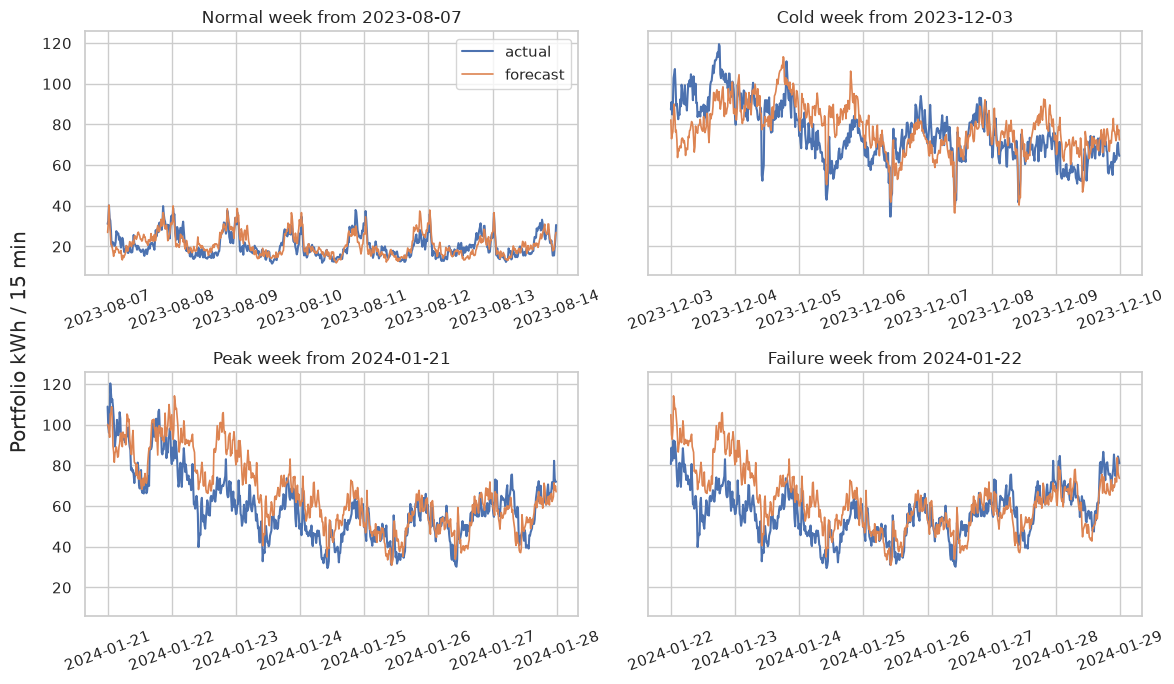

In [6]:
w = pred[pred.model == winner].copy(); w['date'] = w.target_timestamp.dt.floor('D'); w['abs_error'] = (w.actual-w.prediction).abs()
daily = w.groupby('date').agg(mae=('abs_error','mean'), peak=('actual','max'), mean=('actual','mean'))
winter = daily[daily.index.month.isin([12,1,2])]
chosen = {'normal': (daily.mae-daily.mae.median()).abs().idxmin(), 'cold': winter['mean'].idxmax(), 'peak': daily.peak.idxmax(), 'failure': daily.mae.idxmax()}
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
for ax, (label, day) in zip(axes.flat, chosen.items()):
    view = w[(w.target_timestamp >= day) & (w.target_timestamp < day + pd.Timedelta(days=7))]
    ax.plot(view.target_timestamp, view.actual, label='actual', lw=1.5); ax.plot(view.target_timestamp, view.prediction, label='forecast', lw=1.2)
    ax.set_title(f'{label.title()} week from {day.date()}'); ax.tick_params(axis='x', rotation=20)
axes[0,0].legend(); fig.supylabel('Portfolio kWh / 15 min'); plt.tight_layout(); plt.show()

## 9–10. Error by horizon, season, temperature, hour, PV, intervention, and household

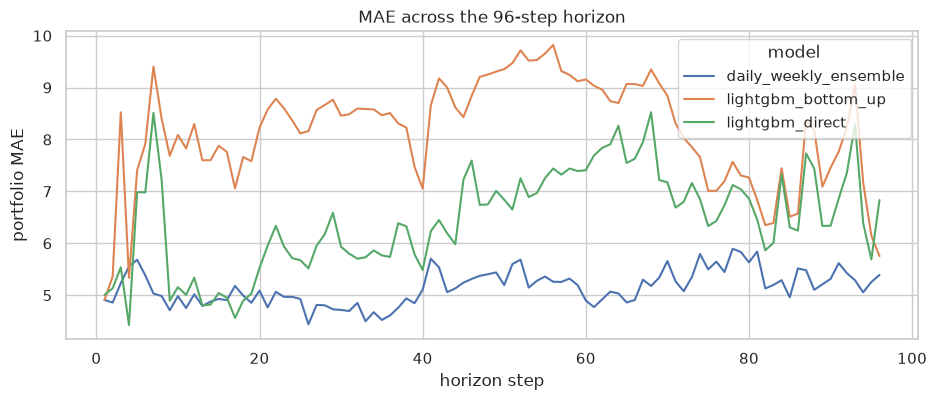

In [7]:
h = sliced[(sliced['slice']=='horizon_step') & (sliced.model.isin([winner,'lightgbm_bottom_up','lightgbm_direct']))].copy(); h['slice_value'] = pd.to_numeric(h.slice_value)
fig, ax = plt.subplots(figsize=(11, 4)); sns.lineplot(data=h, x='slice_value', y='mae', hue='model', ax=ax)
ax.set(title='MAE across the 96-step horizon', xlabel='horizon step', ylabel='portfolio MAE'); plt.show()

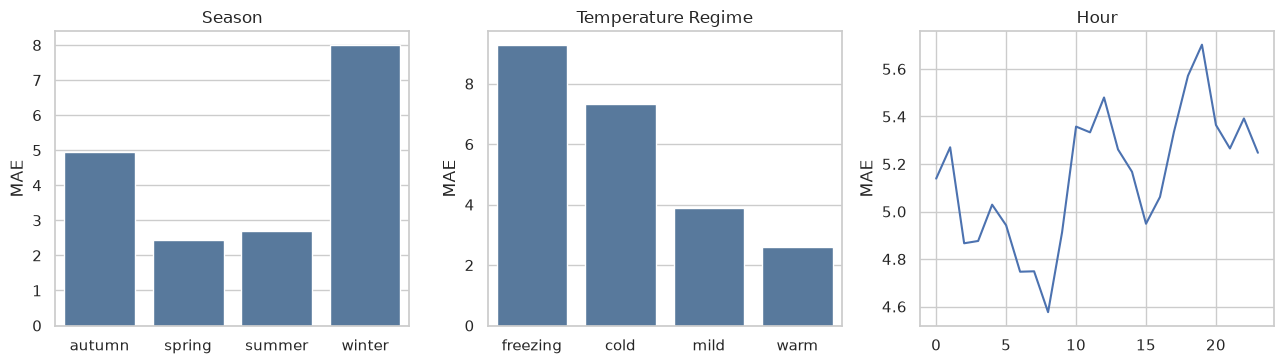

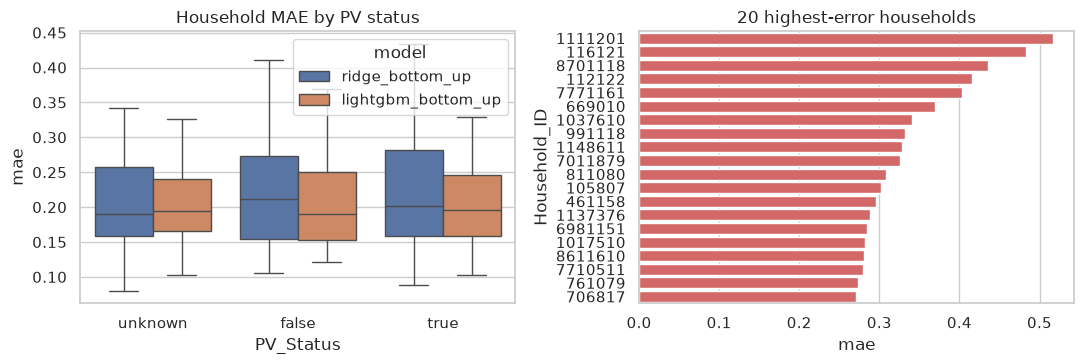

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, key in zip(axes, ['season','temperature_regime','hour']):
    part = sliced[(sliced['slice']==key) & (sliced.model==winner)].copy()
    if key == 'hour': part['slice_value'] = pd.to_numeric(part.slice_value); sns.lineplot(data=part, x='slice_value', y='mae', ax=ax)
    else: sns.barplot(data=part, x='slice_value', y='mae', color='#4c78a8', ax=ax)
    ax.set(title=key.replace('_',' ').title(), xlabel='', ylabel='MAE')
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.boxplot(data=household, x='PV_Status', y='mae', hue='model', showfliers=False, ax=axes[0]); axes[0].set_title('Household MAE by PV status')
top = household[household.model=='lightgbm_bottom_up'].nlargest(20, 'mae')
sns.barplot(data=top, y='Household_ID', x='mae', color='#e45756', ax=axes[1]); axes[1].set_title('20 highest-error households')
plt.tight_layout(); plt.show()

## 11–12. Feature families, residual bias, and autocorrelation

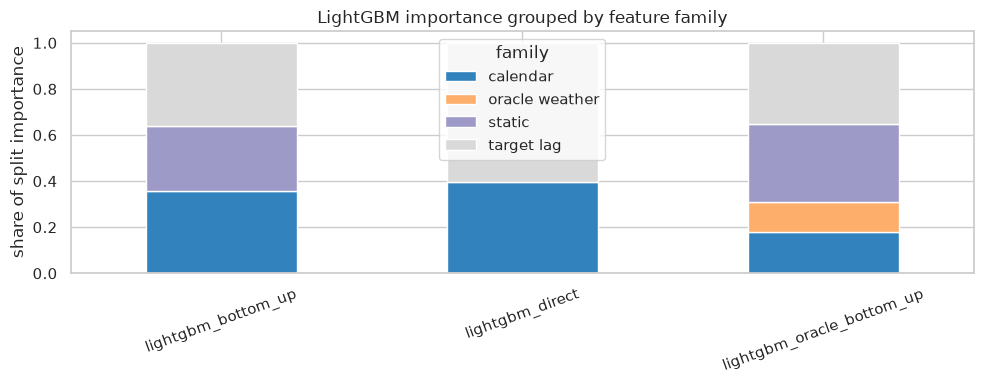

In [9]:
def family(name):
    if name.startswith('lag_'): return 'target lag'
    if name.startswith('weather_'): return 'oracle weather'
    if name.startswith('static_'): return 'static'
    return 'calendar'
imp = importance.copy(); imp['family'] = imp.feature.map(family)
grouped = imp.groupby(['model','family'], as_index=False).importance.sum()
grouped['share'] = grouped.importance / grouped.groupby('model').importance.transform('sum')
fig, ax = plt.subplots(figsize=(10,4)); grouped.pivot(index='model',columns='family',values='share').fillna(0).plot.bar(stacked=True, ax=ax, colormap='tab20c')
ax.set(title='LightGBM importance grouped by feature family', ylabel='share of split importance', xlabel=''); ax.tick_params(axis='x', rotation=20); plt.tight_layout(); plt.show()

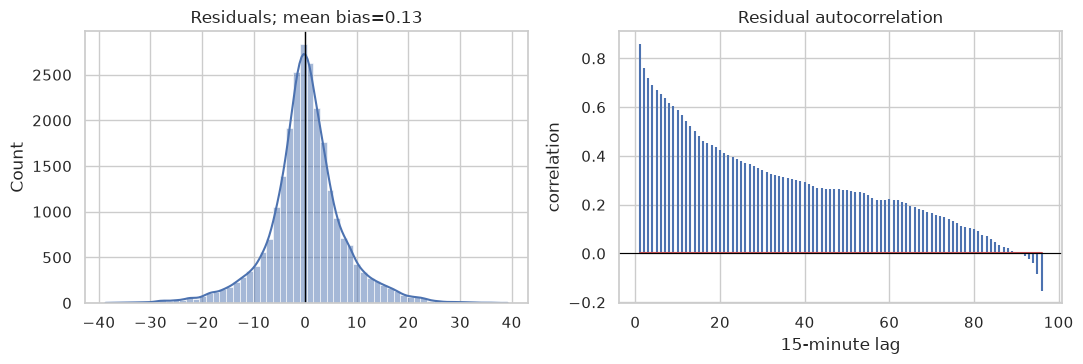

In [10]:
res = (w.actual-w.prediction).dropna().to_numpy(); max_lag = 96
acf = [np.corrcoef(res[:-lag], res[lag:])[0,1] for lag in range(1,max_lag+1)]
fig, axes = plt.subplots(1,2,figsize=(11,3.8))
sns.histplot(res, bins=60, kde=True, ax=axes[0]); axes[0].axvline(0,color='black',lw=1); axes[0].set_title(f'Residuals; mean bias={res.mean():.2f}')
axes[1].stem(np.arange(1,max_lag+1), acf, markerfmt=' '); axes[1].axhline(0,color='black',lw=.8); axes[1].set(title='Residual autocorrelation',xlabel='15-minute lag',ylabel='correlation')
plt.tight_layout(); plt.show()

## 13. Horizon-specific split-conformal intervals
Absolute residual radii are calibrated independently at each of the 96 horizons. The plotted bounds correspond to a nominal central 90% interval; the point forecast is the median output.

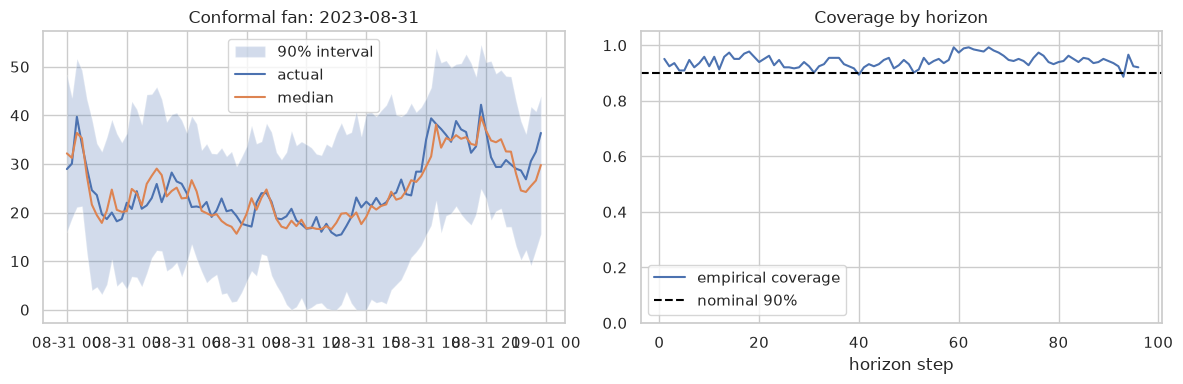

,model,interval_coverage,mean_interval_width
0,daily_weekly_ensemble,0.943024,31.114622


In [11]:
bounded = pred[(pred.model==winner) & pred.lower.notna()].copy()
fan_day = bounded.groupby(bounded.origin).apply(lambda x: (x.upper-x.lower).mean(), include_groups=False).sort_values().index[len(bounded.origin.unique())//2]
fan = bounded[bounded.origin==fan_day]
interval_h = sliced[(sliced['slice']=='interval_horizon_step') & (sliced.model==winner)].copy(); interval_h['slice_value'] = pd.to_numeric(interval_h.slice_value)
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].fill_between(fan.target_timestamp, fan.lower, fan.upper, alpha=.25, label='90% interval'); axes[0].plot(fan.target_timestamp,fan.actual,label='actual'); axes[0].plot(fan.target_timestamp,fan.prediction,label='median'); axes[0].set_title(f'Conformal fan: {fan_day.date()}'); axes[0].legend()
axes[1].plot(interval_h.slice_value, interval_h.interval_coverage, label='empirical coverage'); axes[1].axhline(.9,color='black',ls='--',label='nominal 90%'); axes[1].set(ylim=(0,1.05),title='Coverage by horizon',xlabel='horizon step'); axes[1].legend()
plt.tight_layout(); plt.show()
overall.loc[overall.model==winner, ['model','interval_coverage','mean_interval_width']]

## 14–15. Broader-cohort robustness, decision, and next experiment

In [12]:
robust = config['robustness']; primary = overall.set_index('model').loc[winner]
summary = pd.DataFrame([{'experiment':'primary two-year cohort','households':139,'MAE':primary.mae,'WAPE':primary.wape,'bias':primary.bias}, {'experiment':'one-year robustness cohort','households':robust['cohort_size'],'MAE':robust['metrics']['mae'],'WAPE':robust['metrics']['wape'],'bias':robust['metrics']['bias']}])
display(summary.round(3))
print(f"DECISION: retain {winner} as the operational champion. It was selected only on validation data and achieves test WAPE {primary.wape:.1%}.")
print(f"UNCERTAINTY: empirical 90% coverage is {primary.interval_coverage:.1%}, with mean width {primary.mean_interval_width:.1f} portfolio kWh.")
print(f"NEXT EXPERIMENT: obtain archived day-ahead weather forecasts and repeat the oracle ablation fairly. Realized weather reduced global-model MAE by {(safe-oracle)/safe:.1%}, but is not deployable.")
print('GATE: run the production 400-tree/all-origin configuration before deployment; the checked-in execution is discussion evidence, not a production sign-off.')

,experiment,households,MAE,WAPE,bias
0,primary two-year cohort,139,5.150,0.134,-0.126
1,one-year robustness cohort,343,18.042,0.118,0.946


DECISION: retain daily_weekly_ensemble as the operational champion. It was selected only on validation data and achieves test WAPE 13.4%.
UNCERTAINTY: empirical 90% coverage is 94.3%, with mean width 31.1 portfolio kWh.
NEXT EXPERIMENT: obtain archived day-ahead weather forecasts and repeat the oracle ablation fairly. Realized weather reduced global-model MAE by 20.8%, but is not deployable.
GATE: run the production 400-tree/all-origin configuration before deployment; the checked-in execution is discussion evidence, not a production sign-off.
